In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df_imp = pd.read_csv("Data/impressions.csv") 

In [5]:
df_conv = pd.read_csv("Data/conversions.csv") 

In [6]:
df_imp['imp_date'] = pd.to_datetime(df_imp['timestamp'],unit='s')
df_conv['conv_date'] = pd.to_datetime(df_conv['timestamp'],unit='s')


In [9]:
del df_imp['timestamp']
del df_conv['timestamp']


In [12]:
comb_df1 = pd.merge(df_imp, df_conv, on='user_id', suffixes=('_imp', '_conv'))
comb_df1

,auction_id,message_id,user_id,spend,imp_date,conversion_id,conversion_name,conv_date
0,1031386905892227659,651411,32262,0.00029,2018-07-09 07:30:18,285724,visite,2018-07-09 12:18:59
1,7002424012566036536,336028,32262,0.00061,2018-07-09 09:36:22,285724,visite,2018-07-09 12:18:59
2,2466402414753153137,336028,32262,0.00061,2018-07-11 18:17:15,285724,visite,2018-07-09 12:18:59
3,2041601436001243868,651411,32262,0.00065,2018-07-12 07:20:37,285724,visite,2018-07-09 12:18:59
4,1369830363778070617,335881,29806,0.00064,2018-07-09 06:56:34,285724,visite,2018-07-13 15:10:55
...,...,...,...,...,...,...,...,...
16164,6619127839878516874,336028,48881,0.00029,2018-07-15 04:08:06,285724,visite,2018-07-11 06:03:34
16165,6685580618585886334,336028,41188,0.00007,2018-07-15 04:25:20,285724,visite,2018-07-15 10:19:34
16166,8920701388428247600,336028,40278,0.00024,2018-07-15 04:02:00,760041,vente,2018-07-12 05:11:50
16167,8147333642810125594,336028,38818,0.00022,2018-07-15 19:04:23,285724,visite,2018-07-14 14:48:10


In [13]:
comb_df1 = comb_df1[comb_df1['conv_date'] > comb_df1['imp_date']]
comb_df1

,auction_id,message_id,user_id,spend,imp_date,conversion_id,conversion_name,conv_date
0,1031386905892227659,651411,32262,0.00029,2018-07-09 07:30:18,285724,visite,2018-07-09 12:18:59
1,7002424012566036536,336028,32262,0.00061,2018-07-09 09:36:22,285724,visite,2018-07-09 12:18:59
4,1369830363778070617,335881,29806,0.00064,2018-07-09 06:56:34,285724,visite,2018-07-13 15:10:55
5,6770935537018086228,335881,29806,0.00064,2018-07-09 12:47:21,285724,visite,2018-07-13 15:10:55
6,6955722404886252502,651411,29806,0.00025,2018-07-10 06:14:26,285724,visite,2018-07-13 15:10:55
...,...,...,...,...,...,...,...,...
16005,6682814574162461308,336028,88411,0.00029,2018-07-15 05:00:14,760041,vente,2018-07-15 14:10:38
16012,932252282285917441,336028,70702,0.00077,2018-07-15 05:27:20,285724,visite,2018-07-15 10:45:02
16017,3093674932027636955,336028,61995,0.00088,2018-07-15 09:33:18,285724,visite,2018-07-15 19:09:21
16154,3744858819027424781,336028,65719,0.00031,2018-07-15 15:15:16,760041,vente,2018-07-15 18:29:22


In [14]:
comb_df1.conversion_name.value_counts()

visite    6582
vente     3000
Name: conversion_name, dtype: int64

In [15]:
visit_df = comb_df1[comb_df1.conversion_name == 'visite']
visit_df

,auction_id,message_id,user_id,spend,imp_date,conversion_id,conversion_name,conv_date
0,1031386905892227659,651411,32262,0.00029,2018-07-09 07:30:18,285724,visite,2018-07-09 12:18:59
1,7002424012566036536,336028,32262,0.00061,2018-07-09 09:36:22,285724,visite,2018-07-09 12:18:59
4,1369830363778070617,335881,29806,0.00064,2018-07-09 06:56:34,285724,visite,2018-07-13 15:10:55
5,6770935537018086228,335881,29806,0.00064,2018-07-09 12:47:21,285724,visite,2018-07-13 15:10:55
6,6955722404886252502,651411,29806,0.00025,2018-07-10 06:14:26,285724,visite,2018-07-13 15:10:55
...,...,...,...,...,...,...,...,...
15983,1279658104782189436,530308,55450,0.00078,2018-07-14 16:58:05,285724,visite,2018-07-15 09:33:21
16000,9061462323265167586,336028,45160,0.00044,2018-07-14 18:09:53,285724,visite,2018-07-15 09:03:45
16012,932252282285917441,336028,70702,0.00077,2018-07-15 05:27:20,285724,visite,2018-07-15 10:45:02
16017,3093674932027636955,336028,61995,0.00088,2018-07-15 09:33:18,285724,visite,2018-07-15 19:09:21


In [16]:
sales_df = comb_df1[comb_df1.conversion_name == 'vente']
sales_df

,auction_id,message_id,user_id,spend,imp_date,conversion_id,conversion_name,conv_date
8,1438837428669767611,336028,45131,0.00059,2018-07-09 07:30:00,760041,vente,2018-07-13 10:06:36
9,148292683650538422,335881,82045,0.00042,2018-07-09 07:15:17,760041,vente,2018-07-14 15:26:52
13,1674276855095463387,336028,34400,0.00117,2018-07-09 07:23:04,760041,vente,2018-07-15 06:08:57
14,6867906630309906385,336028,34400,0.00117,2018-07-09 07:23:04,760041,vente,2018-07-15 06:08:57
15,9106670751356451012,336028,34400,0.00117,2018-07-09 07:22:58,760041,vente,2018-07-15 06:08:57
...,...,...,...,...,...,...,...,...
15969,1794470695222602525,530308,77963,0.00077,2018-07-14 10:55:32,760041,vente,2018-07-14 12:37:30
15985,2859407366432208002,336028,24886,0.00050,2018-07-14 17:29:21,760041,vente,2018-07-15 16:39:46
15986,6147429995898792522,336028,24886,0.00061,2018-07-15 04:23:18,760041,vente,2018-07-15 16:39:46
16005,6682814574162461308,336028,88411,0.00029,2018-07-15 05:00:14,760041,vente,2018-07-15 14:10:38


In [17]:
sales_df.spend.sum()

1.6483199999999965

In [18]:
visit_df.spend.sum()

3.652939999999991

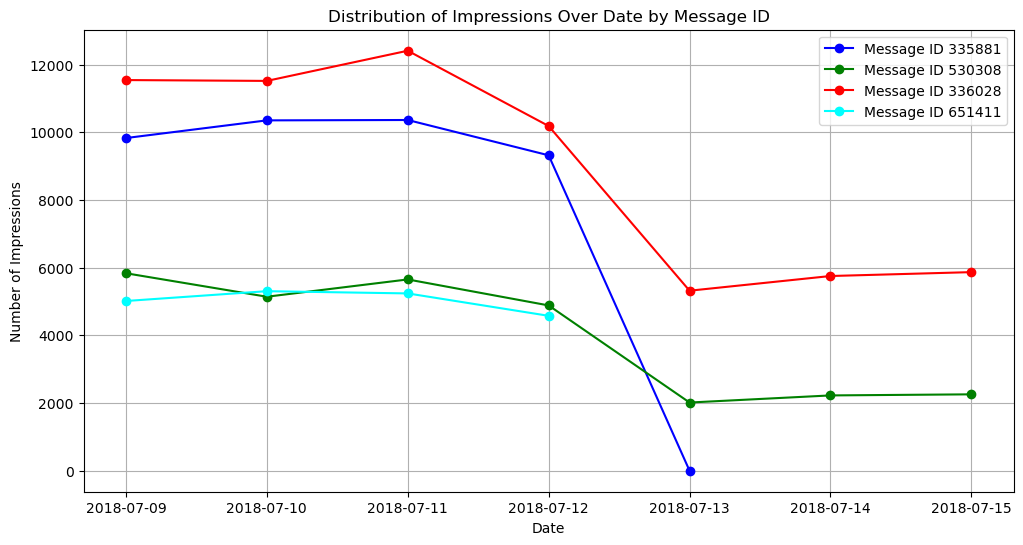

In [46]:
# impressions over date for different message_ids
colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'black', 'orange', 'purple', 'brown']
color_cycle = plt.cycler(color=colors)

plt.figure(figsize=(12, 6))
plt.rc('axes', prop_cycle=color_cycle)

for message_id in df_imp['message_id'].unique():
    subset = df_imp[df_imp['message_id'] == message_id]
    subset = subset.groupby(subset['imp_date'].dt.date).size()
    plt.plot(subset.index, subset.values, label=f'Message ID {message_id}', marker='o')

plt.xlabel('Date')
plt.ylabel('Number of Impressions')
plt.title('Distribution of Impressions Over Date by Message ID')
plt.legend()
plt.grid(True)
plt.show()


In [24]:
time_periods = df_imp.groupby('message_id')['imp_date'].agg(['min', 'max'])

# Show the time periods for each message_id
time_periods

,min,max
message_id,,
335881,2018-07-09 01:03:32,2018-07-13 06:34:52
336028,2018-07-09 00:09:28,2018-07-15 19:05:24
530308,2018-07-09 03:00:23,2018-07-15 19:05:19
651411,2018-07-09 00:44:42,2018-07-12 17:20:22


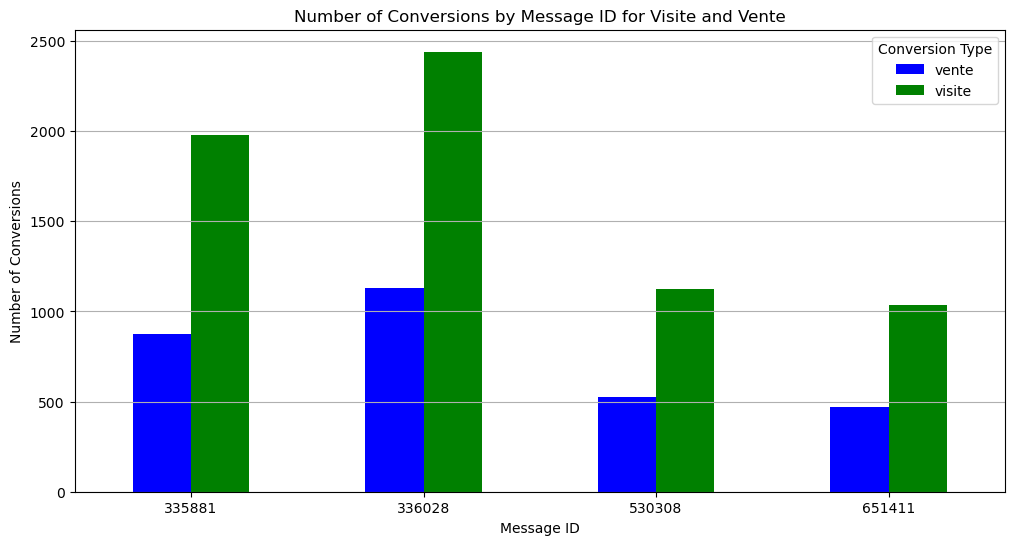

In [25]:
# Group by message_id and conversion_name, and count the number of conversions
conversion_counts = comb_df1.groupby(['message_id', 'conversion_name']).size().unstack(fill_value=0)

# Plotting the results
conversion_counts.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Message ID')
plt.ylabel('Number of Conversions')
plt.title('Number of Conversions by Message ID for Visite and Vente')
plt.xticks(rotation=0)
plt.legend(title='Conversion Type')
plt.grid(axis='y')
plt.show()

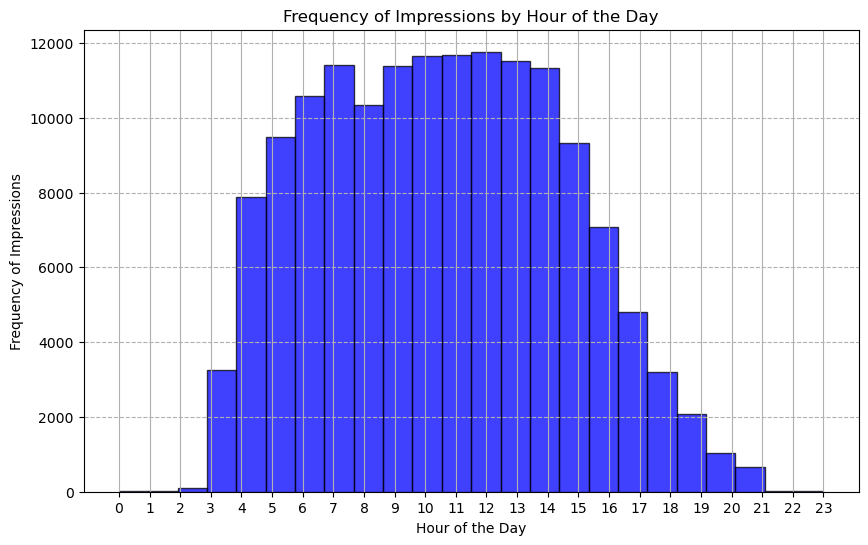

In [28]:
# Extract hour from the date
df_imp['hour'] = df_imp['imp_date'].dt.hour

# Plotting the frequency of impressions over time (hour of the day)
plt.figure(figsize=(10, 6))
df_imp['hour'].hist(bins=24, range=(0,23), alpha=0.75, color='blue', edgecolor='black')
plt.xlabel('Hour of the Day')
plt.ylabel('Frequency of Impressions')
plt.title('Frequency of Impressions by Hour of the Day')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--')
plt.show()


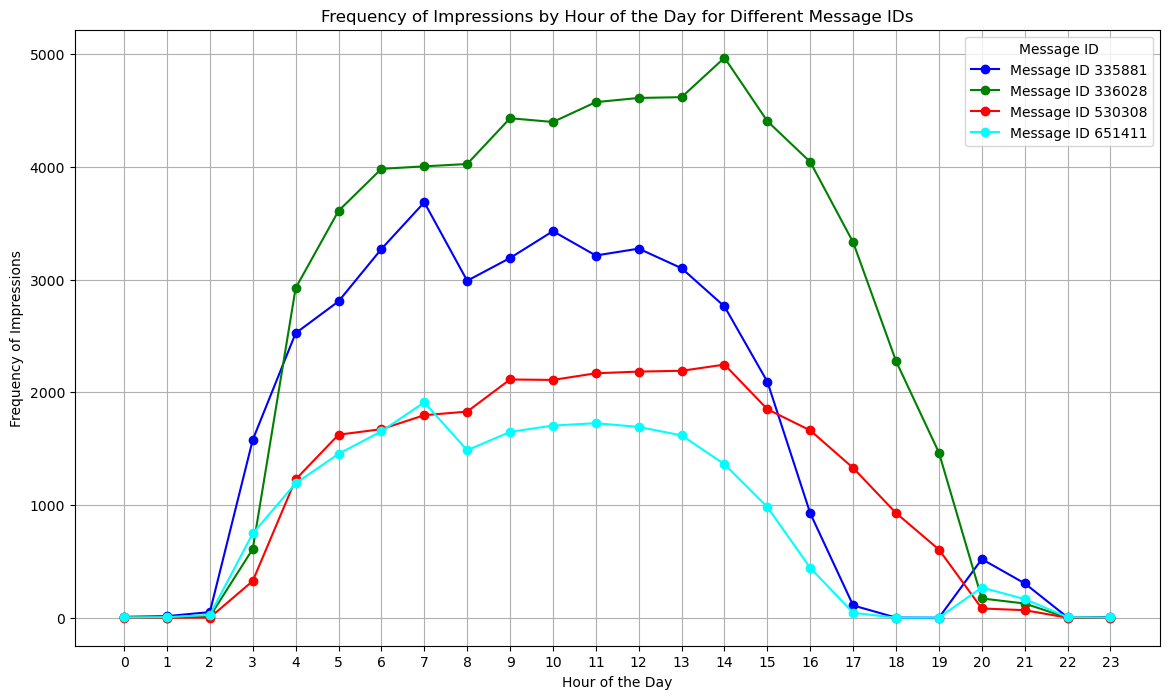

In [29]:
# Grouping data by message_id and hour, then counting impressions
hourly_impressions = df_imp.groupby(['message_id', 'hour']).size().unstack(fill_value=0)

# Plotting the distribution of impressions over hours for different message_ids
plt.figure(figsize=(14, 8))
for message_id in hourly_impressions.index:
    plt.plot(hourly_impressions.columns, hourly_impressions.loc[message_id], label=f'Message ID {message_id}', marker='o')

plt.xlabel('Hour of the Day')
plt.ylabel('Frequency of Impressions')
plt.title('Frequency of Impressions by Hour of the Day for Different Message IDs')
plt.xticks(range(0, 24))
plt.legend(title='Message ID')
plt.grid(True)
plt.show()

In [30]:
df_conv

,user_id,conversion_id,conversion_name,conv_date
0,13026,285724,visite,2018-07-09 07:31:23
1,14117,285724,visite,2018-07-09 07:12:20
2,15472,285724,visite,2018-07-09 07:00:04
3,16213,760041,vente,2018-07-09 06:55:28
4,16970,285724,visite,2018-07-09 07:16:57
...,...,...,...,...
8888,82493,285724,visite,2018-07-15 00:52:32
8889,84722,760041,vente,2018-07-14 21:41:11
8890,88614,285724,visite,2018-07-14 23:34:22
8891,89556,285724,visite,2018-07-15 00:51:26


In [31]:
df_imp

,auction_id,message_id,user_id,spend,imp_date,hour
0,1011527229225982812,335881,81763,0.00048,2018-07-09 07:14:28,7
1,1019125075080749328,530308,75065,0.00021,2018-07-09 07:09:24,7
2,1026658047695643709,336028,36559,0.00052,2018-07-09 07:10:52,7
3,1031386905892227659,651411,32262,0.00029,2018-07-09 07:30:18,7
4,1037113241780132055,335881,50281,0.00068,2018-07-09 06:58:23,6
...,...,...,...,...,...,...
150624,8099454765208265847,336028,48750,0.00061,2018-07-15 19:04:45,19
150625,8460652359784980519,336028,52619,0.00029,2018-07-15 19:04:43,19
150626,8588427627177821422,336028,79679,0.00056,2018-07-15 19:05:12,19
150627,8591880332338052557,336028,78716,0.00010,2018-07-15 19:03:25,19


In [33]:
comb_df1['time_diff_hours'] = comb_df1['conv_date'] - comb_df1['imp_date']


/var/folders/d7/5lnxp9g912g0c9nbw2ynhg5m0000gn/T/ipykernel_13520/3283399907.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comb_df1['time_diff_hours'] = comb_df1['conv_date'] - comb_df1['imp_date']


In [34]:
comb_df1

,auction_id,message_id,user_id,spend,imp_date,conversion_id,conversion_name,conv_date,time_diff_hours
0,1031386905892227659,651411,32262,0.00029,2018-07-09 07:30:18,285724,visite,2018-07-09 12:18:59,0 days 04:48:41
1,7002424012566036536,336028,32262,0.00061,2018-07-09 09:36:22,285724,visite,2018-07-09 12:18:59,0 days 02:42:37
4,1369830363778070617,335881,29806,0.00064,2018-07-09 06:56:34,285724,visite,2018-07-13 15:10:55,4 days 08:14:21
5,6770935537018086228,335881,29806,0.00064,2018-07-09 12:47:21,285724,visite,2018-07-13 15:10:55,4 days 02:23:34
6,6955722404886252502,651411,29806,0.00025,2018-07-10 06:14:26,285724,visite,2018-07-13 15:10:55,3 days 08:56:29
...,...,...,...,...,...,...,...,...,...
16005,6682814574162461308,336028,88411,0.00029,2018-07-15 05:00:14,760041,vente,2018-07-15 14:10:38,0 days 09:10:24
16012,932252282285917441,336028,70702,0.00077,2018-07-15 05:27:20,285724,visite,2018-07-15 10:45:02,0 days 05:17:42
16017,3093674932027636955,336028,61995,0.00088,2018-07-15 09:33:18,285724,visite,2018-07-15 19:09:21,0 days 09:36:03
16154,3744858819027424781,336028,65719,0.00031,2018-07-15 15:15:16,760041,vente,2018-07-15 18:29:22,0 days 03:14:06


In [35]:
average_conversion_time = comb_df1.groupby('message_id')['time_diff_hours'].mean()


In [36]:
average_conversion_time


message_id
335881   2 days 13:04:34.096491228
336028   2 days 09:19:08.982647635
530308   2 days 11:48:24.706060606
651411   2 days 13:34:59.695825049
Name: time_diff_hours, dtype: timedelta64[ns]

In [37]:
average_conversion_time_type = comb_df1.groupby(['message_id', 'conversion_name'])['time_diff_hours'].mean().unstack()
average_conversion_time_type

conversion_name,vente,visite
message_id,,
335881,2 days 12:52:36.572737686,2 days 13:09:50.939301972
336028,2 days 08:47:17.977031802,2 days 09:33:55.200737402
530308,2 days 10:45:39.017175572,2 days 12:17:37.122557726
651411,2 days 12:16:56.394904458,2 days 14:10:24.777456647


In [38]:
average_conversion_time_type.vente.mean()

Timedelta('2 days 11:10:37.490462379')

In [39]:
average_conversion_time_type.visite.mean()

Timedelta('2 days 12:17:57.010013436')

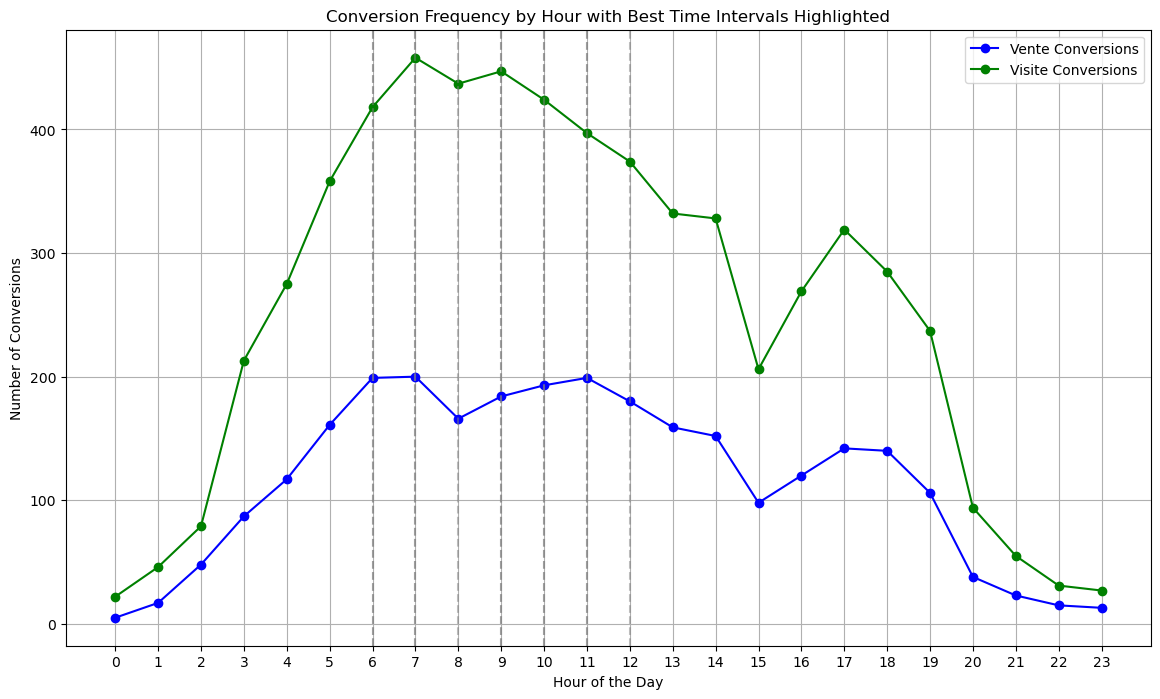

(None, {'vente': [6, 7, 9, 10, 11, 12], 'visite': [6, 7, 8, 9, 10, 11]})

In [43]:
# Extract hour from the date for conversions
df_conv['hour'] = df_conv['conv_date'].dt.hour

# Group by hour and conversion_name, count conversions
hourly_conversions = df_conv.groupby(['hour', 'conversion_name']).size().unstack(fill_value=0)

# Determine the best time intervals (top 25% of hours for each conversion type)
best_hours_conversions = {}
for conversion_type in hourly_conversions.columns:
    threshold = np.percentile(hourly_conversions[conversion_type], 75)
    best_hours_conversions[conversion_type] = hourly_conversions.index[hourly_conversions[conversion_type] >= threshold].tolist()

# Plotting the conversion frequency over time with best intervals highlighted
plt.figure(figsize=(14, 8))
for conversion_type in hourly_conversions.columns:
    plt.plot(hourly_conversions.index, hourly_conversions[conversion_type], label=f'{conversion_type.capitalize()} Conversions', marker='o')
    # Highlight best hours
    best_intervals = best_hours_conversions[conversion_type]
    for hour in best_intervals:
        plt.axvline(x=hour, color='gray', linestyle='--', alpha=0.5)

plt.xlabel('Hour of the Day')
plt.ylabel('Number of Conversions')
plt.title('Conversion Frequency by Hour with Best Time Intervals Highlighted')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.show(), best_hours_conversions


<Figure size 1000x600 with 0 Axes>

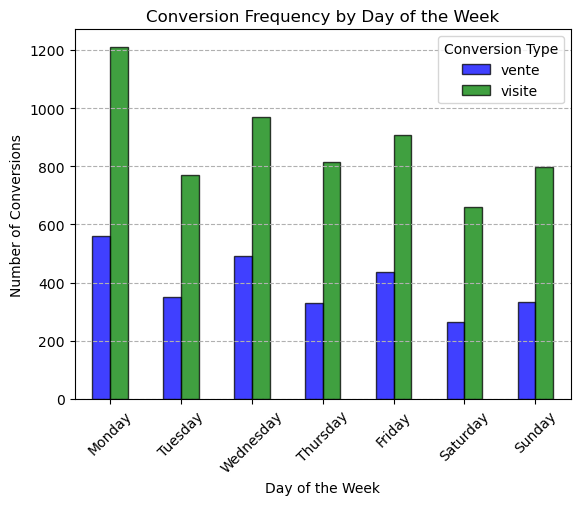

In [45]:
# Extract day of the week from the date for conversions (Monday=0, Sunday=6)
df_conv['day_of_week'] = df_conv['conv_date'].dt.dayofweek

# Group by day of the week and conversion_name, count conversions
daily_conversions = df_conv.groupby(['day_of_week', 'conversion_name']).size().unstack(fill_value=0)

# Mapping days of the week for better readability
day_mapping = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
daily_conversions.index = [day_mapping[day] for day in daily_conversions.index]

# Plotting the conversion frequency by day with best days highlighted
plt.figure(figsize=(10, 6))
daily_conversions.plot(kind='bar', alpha=0.75, edgecolor='black')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Conversions')
plt.title('Conversion Frequency by Day of the Week')
plt.xticks(rotation=45)
plt.legend(title='Conversion Type')
plt.grid(axis='y', linestyle='--')